In [1]:
import xarray as xr
import intake
import matplotlib.pyplot as plt
import dask
import dask.distributed
from dask.distributed import Client, LocalCluster
import sys; import os
sys.path.append(os.path.dirname('../workflow'))
from workflow.scripts.utils import model_levels_to_pressure_levels
from pyclim_noresm.general_util_funcs import global_avg
import matplotlib as mpl

In [2]:
dask.config.set({'distributed.comm.timeouts.connect': '10s'})  # 10 seconds for connecting
dask.config.set({'distributed.comm.timeouts.tcp': '30s'})      # 30 seconds for TCP ops
dask.config.set({'distributed.worker.retries': 3})             # Retry failed tasks up to 3 times

In [3]:
cluster = LocalCluster(n_workers = 2, threads_per_worker=1, memory_limit='20GB')

In [4]:
client = Client(cluster)

In [25]:
cat = intake.open_esm_datastore("../catalogues/merge_CMIP6.json")
cat = cat.search(source_id='NorESM2-LM', experiment_id=['piClim-control','piClim-2xdust'])
cli = cat.search(source_id='NorESM2-LM', variable_id=['cli','clw'], table_id='Amon')
ta = cat.search(source_id='NorESM2-LM', variable_id=['ta'], table_id='Amon')
ps = cat.search(source_id='NorESM2-LM', variable_id=['ps'], table_id='Amon')

In [9]:
cli_exp = cli.search(experiment_id='piClim-2xdust', member_id='r1i1p2f1').to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
cli_exp_ds = cli_exp[list(cli_exp.keys())[0]].resample(time='YE').mean().compute()
cli_exp_ds = cli_exp_ds.isel(member_id=0)
ta_exp = ta.search(experiment_id='piClim-2xdust', member_id='r1i1p2f1').to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
ta_exp_ds = ta_exp[list(ta_exp)[0]].resample(time='YE').mean().compute()
ta_exp_ds = ta_exp_ds.isel(member_id=0)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [6]:
timeranges= ['001101-002012','002101-003012','003101-004012','004101-005012']
cli_ctrl = cli.search(experiment_id='piClim-control', member_id='r1i1p2f1', time_range=timeranges).to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
cli_ctrl_ds = cli_ctrl[list(cli_ctrl.keys())[0]].resample(time='YE').mean().compute()
cli_ctrl_ds = cli_ctrl_ds.isel(member_id=0)
ta_ctrl = ta.search(experiment_id='piClim-control', member_id='r1i1p2f1', time_range=timeranges).to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
ta_ctrl_ds = ta_ctrl[list(ta_ctrl)[0]].resample(time='YE').mean().compute()
ta_ctrl_ds = ta_ctrl_ds.isel(member_id=0)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/geocat/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/geocat/share/proj failed



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [26]:
ps_ctrl = ps.search(experiment_id='piClim-control', member_id='r1i1p2f1', time_range=timeranges).to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
ps_ctrl_ds = ps_ctrl[list(ps_ctrl)[0]].resample(time='YE').mean().compute()
ps_ctrl_ds = ps_ctrl_ds.isel(member_id=0)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [27]:
ps_exp = ps.search(experiment_id='piClim-2xdust', member_id='r1i1p2f1').to_dataset_dict(xarray_open_kwargs={'use_cftime':True})
ps_exp_ds = ps_exp[list(ps_exp)[0]].resample(time='YE').mean().compute()
ps_exp_ds = ps_exp_ds.isel(member_id=0)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.experiment_id.member_id'


In [10]:
def calculate_zonal_mean(data, lat_dim='lat', lon_dim='lon'):
    """
    Calculate the zonal mean of an xarray DataArray.
    
    Parameters:
        data (xarray.DataArray): The input data for which to calculate the zonal mean.
        lat_dim (str): The name of the latitude dimension (default is 'lat').
        lon_dim (str): The name of the longitude dimension (default is 'lon').
    
    Returns:
        xarray.DataArray: Zonal mean of the input data averaged over the longitude dimension.
    """
    # Check if the input is an xarray DataArray
    if isinstance(data, xr.DataArray):
        # Compute the mean over the longitude dimension
        zonal_mean = data.mean(dim=lon_dim)
    else:
        raise TypeError("Input data must be an xarray DataArray")

    return zonal_mean

In [11]:
tam_ctrl_da = calculate_zonal_mean(ta_ctrl_ds.mean(dim='time')['ta'])
tam_exp_da = calculate_zonal_mean(ta_exp_ds.mean(dim='time')['ta'])

In [12]:
diff_ta = tam_exp_da- tam_ctrl_da

In [20]:
clim_ctrl_ds = cli_ctrl_ds.mean(dim='time')
clim_exp_ds = cli_exp_ds.mean(dim='time')

In [36]:
clim_ctrl_ds_cli = clim_ctrl_ds.assign_attrs(dict(variable_id='cli'))
clim_ctrl_ds_cli = clim_ctrl_ds_cli.assign(ps=ps_ctrl_ds['ps'].mean(dim='time'))

clim_exp_ds_cli = clim_exp_ds.assign_attrs(dict(variable_id='cli'))
clim_exp_ds_cli = clim_exp_ds_cli.assign(ps=ps_ctrl_ds['ps'].mean(dim='time'))

In [38]:
clim_ctrl_ds_cli_on_plev=model_levels_to_pressure_levels(clim_ctrl_ds_cli,plevels=tam_ctrl_da.plev.values)
zm_clim_ctrl_ds_cli_on_plev = calculate_zonal_mean(clim_ctrl_ds_cli_on_plev['cli'])

clim_exp_ds_cli_on_plev = model_levels_to_pressure_levels(clim_exp_ds_cli, plevels=tam_ctrl_da.plev.values)
zm_clim_exp_ds_cli_on_plev = calculate_zonal_mean(clim_exp_ds_cli_on_plev['cli'])

In [39]:
diff_cli = zm_clim_exp_ds_cli_on_plev - zm_clim_ctrl_ds_cli_on_plev

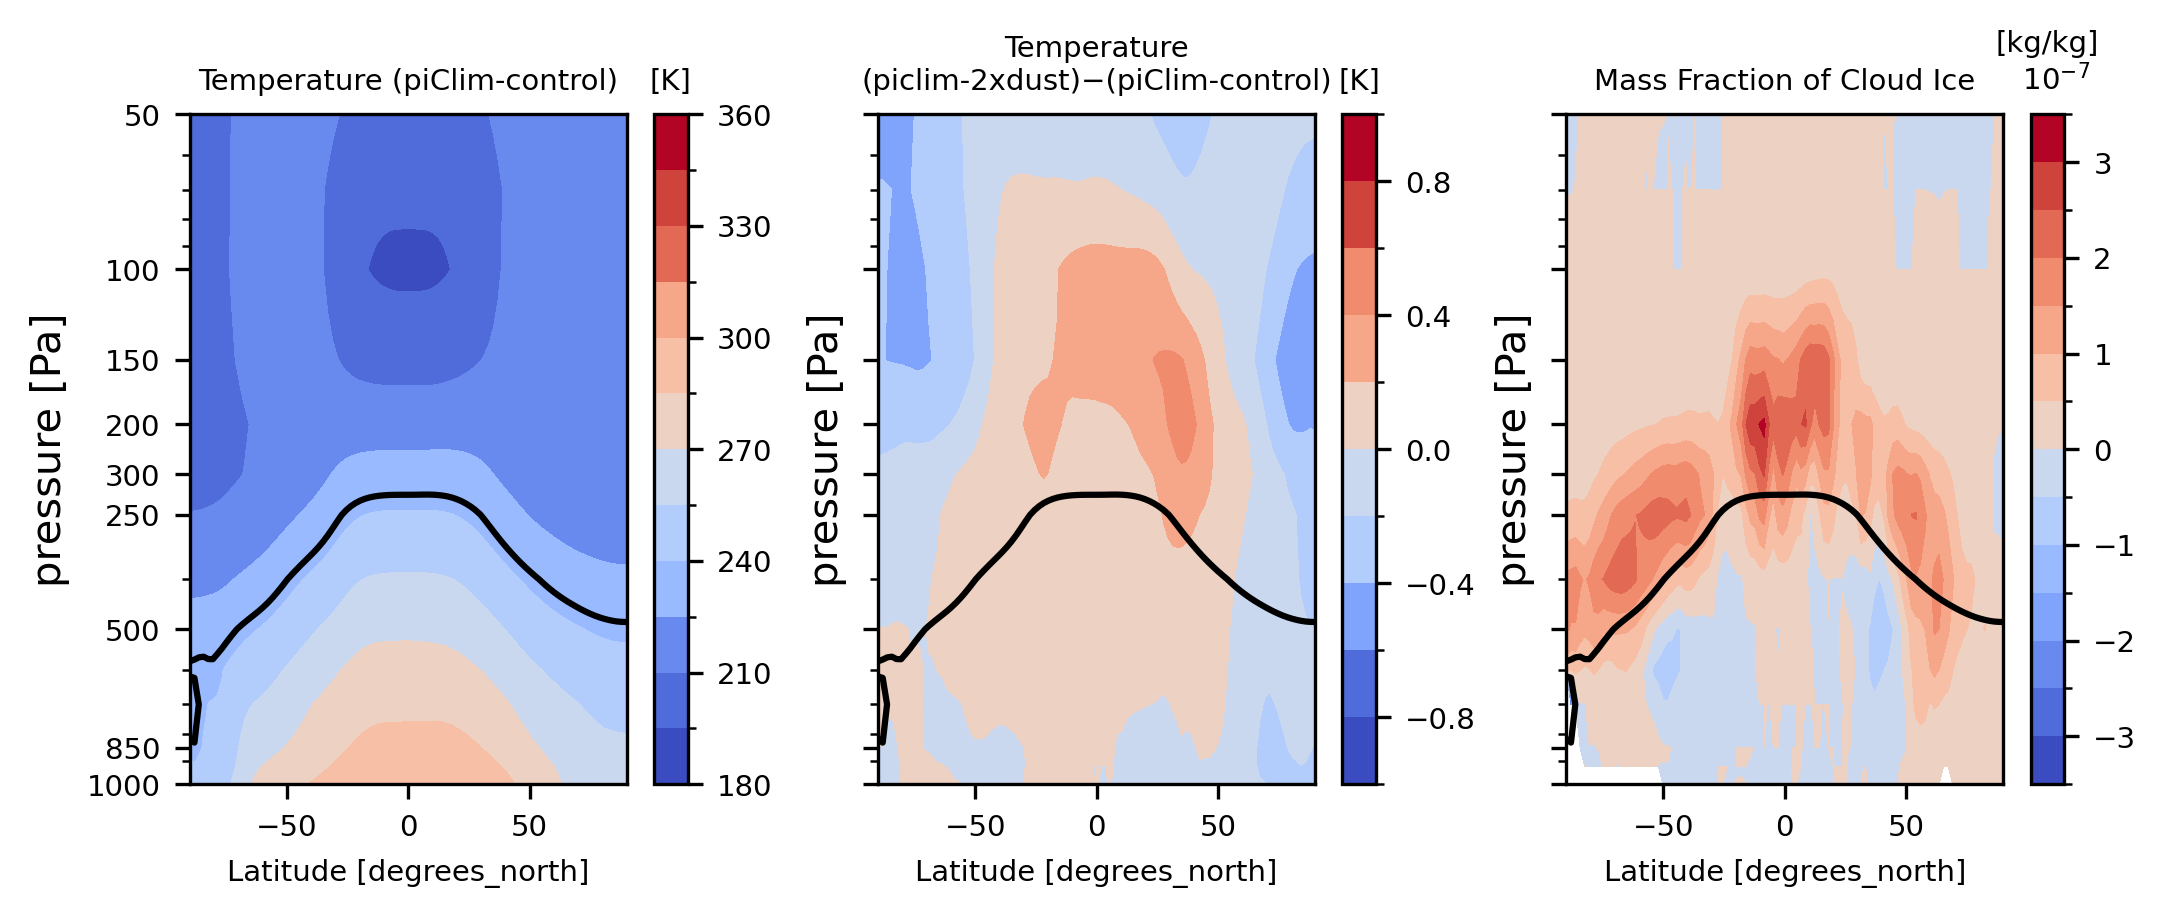

In [112]:
fig, axes = plt.subplots(ncols=3, figsize=(8.27,2.9), dpi=300,sharey=True)

cmap = mpl.cm.coolwarm.resampled(15)
diff_ta.plot.contourf(ax=axes[1],cmap=cmap, levels=11, center=0, vmin=-1, vmax=1)
tam_ctrl_da.plot.contourf(ax=axes[0],cmap=cmap, levels=15, center=273)


(diff_cli*(1e7)).plot.contourf(ax=axes[2],cmap=cmap, levels=15, center=0)

for axi in axes:
    axi.set_title('')
    axi.set_yscale('log')
    axi.set_ylim(100000,5000)
    axi.set_yticks([100000, 85000,50000,30000,25000,20000,15000,10000, 5000])
    axi.set_yticklabels([1000,850,500,250,300,200,150,100, 50])
    
    axi.set_ylabel('')
    axi.set_xlabel('Latitude', fontsize=7)
    axi.tick_params(axis='both', labelsize=7)
    tam_ctrl_da.plot.contour(ax=axi, levels=[236], colors='k', linewidth=1)
axes[0].invert_yaxis()
axes[0].set_title('Temperature (piClim-control)', fontsize=7)
axes[1].set_title('Temperature\n(piclim-2xdust)−(piClim-control)', fontsize=7)
axes[2].set_title('Mass Fraction of Cloud Ice', fontsize=7)
fig.subplots_adjust(wspace=0.26)
fig.get_axes()[3].tick_params(axis='both',labelsize=7)
fig.get_axes()[4].tick_params(axis='both',labelsize=7)
fig.get_axes()[5].tick_params(axis='both',labelsize=7)

fig.get_axes()[3].set_ylabel('')
fig.get_axes()[3].set_title('[K]', fontsize=7)
fig.get_axes()[4].set_ylabel('')
fig.get_axes()[4].set_title('[K]', fontsize=7)
fig.get_axes()[5].set_ylabel('')
fig.get_axes()[5].set_title('[kg/kg]\n  $10^{-7}$', fontsize=7)
plt.savefig('../results/figs/AerChemMIP/change_mass_ice_fraction_NorESM.png',dpi=300, bbox_inches='tight')

In [107]:
print(tam_ctrl_da)

<xarray.DataArray 'ta' (plev: 19, lat: 96)> Size: 7kB
array([[245.37494, 244.41339, 246.1461 , ..., 255.89285, 255.9253 ,
        256.01596],
       [241.76228, 240.81483, 242.52203, ..., 258.274  , 258.23273,
        258.1252 ],
       [237.90395, 236.97162, 238.65154, ..., 257.1031 , 257.02356,
        256.95264],
       ...,
       [218.79642, 218.9544 , 219.27095, ..., 228.97928, 228.96661,
        228.95988],
       [229.56815, 229.6671 , 229.91525, ..., 238.18845, 238.21289,
        238.23155],
       [240.66008, 240.66675, 240.81564, ..., 247.92236, 248.00983,
        248.07356]], dtype=float32)
Coordinates:
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
    member_id  <U8 32B 'r1i1p2f1'
